# Dibujar curva a partir de la curvatura

Se nos anima a hacer un programa al que, introduciendole la curvatura y los tres grados de libertad (pueden ser iguales) sea capaz de dibujar la curva.

In [2]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

def curve_plotter(k, a=0, s_interval = [-10, 10], n=300):
    # Comprobamos la entrada
    if np.isscalar(a):
        a = [a, a, a]
    elif len(a) != 3:
        raise ValueError("'a' debe ser un número o un vector de 3 componentes")
    
		# Definición de theta
    def theta(s):
        return quad(k, a[0], s)[0]
    
    # Definición de alpha
    def alpha(s):
        x_val = quad(lambda t: np.cos(theta(t)), a[1], s)[0]
        y_val = quad(lambda t: np.sin(theta(t)), a[2], s)[0]
        return x_val, y_val
    
    # Valores del parámetro de longitud de arco (s)
    s_vals = np.linspace(s_interval[0], s_interval[1], n)
    
    # Iteramos porque quad no acepta arrays en sus límites
    x_coords = []
    y_coords = []
    
    for s in s_vals:
        x_val, y_val = alpha(s)
        x_coords.append(x_val)
        y_coords.append(y_val)

    # Definimos la gráfica
    plt.figure(figsize=(8, 8))
    
		# Dibujamos los ejes
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    
		# Dibujamos la curva
    plt.plot(x_coords, y_coords, label='Curva reconstruida', color='blue')
		
    plt.axis('equal') 
    plt.title('Representación de curva a partir de su curvatura')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()
    
def funcion(f):
    return lambda s : f(s)

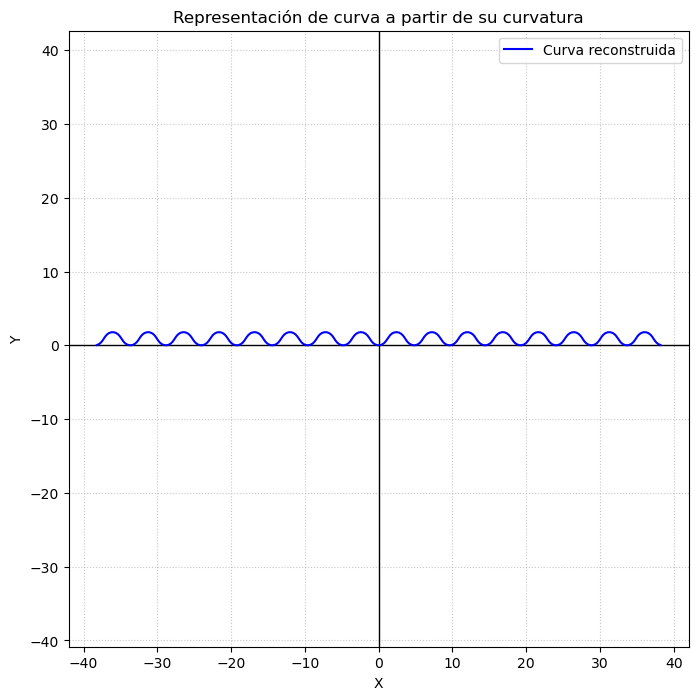

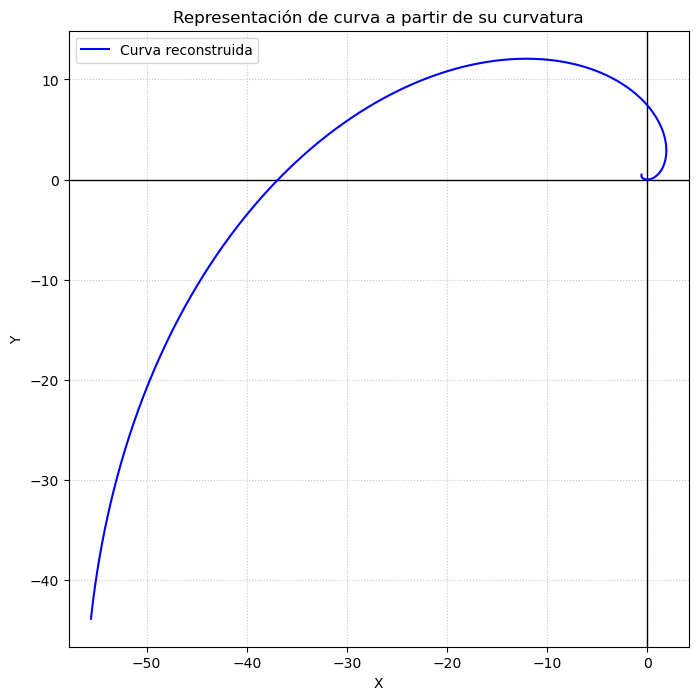

In [20]:
k0 = lambda s : s
k1 = lambda s : s**2

k2 = lambda s : -1	# Constantemente negativa
k3 = lambda s : 0		# Constantemente cero
k4 = lambda s : 1		# Constantemente 1

k5 = funcion(np.cos)
k6 = funcion(np.sin)
k7 = funcion(np.exp)
k8 = funcion(np.log)

k9 = lambda s: 1/(1 + s**2)							# catenaria
k10 = lambda s: 1/s											# espiral logarítmica (a y dominio mayores que 0)
k11 = lambda s: 1 / np.sqrt(1 - s**2)		# Casi cicloide (a y dominio en [-1,1])


# Algunos ejemplos
i=5		# Selector

match i:
	case 0:
		curve_plotter(k0, a=0, s_interval=[-25,25], n=1000)
	case 1:
		curve_plotter(k1, a=0, s_interval=[-10,10], n=1000)
	case 2:
		curve_plotter(k2, a=0, s_interval=[-10,10])
	case 3:
		curve_plotter(k3, a=0, s_interval=[-10,10])
	case 4:
		curve_plotter(k4, a=0, s_interval=[-10,10])
	case 5:
		curve_plotter(k5, a=0, s_interval=[-50, 50])
	case 6:
		curve_plotter(k6, a=[1,1,1], s_interval=[0.1,100], n=500)
	case 7:
		curve_plotter(k7, a=[1,1,1], s_interval=[0.1,100], n=500)
	case 8:
		curve_plotter(k8, a=[1,1,1], s_interval=[0.1,100], n=500)
	case 9:
		curve_plotter(k9, a=[1,1,1], s_interval=[0.1,100], n=500)
	case 10:
		curve_plotter(k10, a=[1,1,1], s_interval=[0.1,100], n=500)
	case 11:
		curve_plotter(k11, a=[1,1,1], s_interval=[0.1,100], n=500)
    
curve_plotter(k10, a=[1,1,1], s_interval=[0.1,100], n=500)